# 4. Visualize CSV (cablelabs2 style)

**Exact same** visualizations as notebook 3 (cablelabs2 style), but for **CSV** data: data summary, **time series** (occupancy over time), **Frequency vs value heatmap** (channel occupancy over time), **distribution** histogram, **correlation heatmap**, and **data preview**. Uses one Data file from `work_dir/csvs/channel_occupancy` plus its Legend.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
from datetime import datetime, timezone
import matplotlib.pyplot as plt

In [2]:
# CSV paths (same as notebook 2)
csvs_dir = Path("work_dir/csvs")
if not csvs_dir.exists():
    csvs_dir = Path("../work_dir/csvs")
occupancy_dir = csvs_dir / "channel_occupancy"
legend_dir = csvs_dir / "frequency_legends"

data_files = sorted(occupancy_dir.glob("Data_*.csv")) if occupancy_dir.exists() else []
if not data_files:
    raise FileNotFoundError(f"No Data_*.csv in {occupancy_dir}")

data_path = data_files[0]  # first file; change index or set data_path = Path("path/to/Data_....csv")
df_raw = pd.read_csv(data_path, header=None)

if len(df_raw) < 61:
    raise ValueError(f"Need at least 61 rows, got {len(df_raw)}")
row0 = df_raw.iloc[0].values
n_col = len(row0)
n_chans = n_col - 6
if n_chans < 1:
    raise ValueError("No channel columns")

ts_start = row0[4]
au_per_hour = np.asarray(row0[5 : 5 + n_chans])
co_rows = df_raw.iloc[1:61]
time_bins = co_rows.iloc[:, 5].values
co_ot = co_rows.iloc[:, 6 : 6 + n_chans].values  # (60, n_chans)

# Legend path: parse Data filename (Data_YYYY_MM_DD_HH_band_dBm.csv)
def legend_base_from_data_path(p):
    m = re.match(r"Data_(\d{4}_\d{2}_\d{2})_(\d{2})_(\d+MHz)_.*\.csv", p.name, re.IGNORECASE)
    if m:
        date_part, hour, band = m.group(1), m.group(2), m.group(3)
        return f"{date_part}_{hour}_{band}"
    return None
base = legend_base_from_data_path(data_path)
legend_path = legend_dir / f"Legend_{base}.csv" if base else None
if legend_path and legend_path.exists():
    leg = pd.read_csv(legend_path, header=None)
    freq_centers = ((leg.iloc[:, 1] + leg.iloc[:, 2]) / 2).values / 1e6
    freq_edges = np.concatenate([[leg.iloc[0, 1] / 1e6], leg.iloc[:, 2].values / 1e6])
else:
    freq_centers = np.arange(n_chans, dtype=float)
    freq_edges = np.arange(n_chans + 1, dtype=float)

time_sec = time_bins - ts_start
t_edges = np.concatenate([time_sec, [time_sec[-1] + 60]])

# Build a dataframe analogous to parquet: one row per (time_bin, channel) for CO; plus we have AU per channel
# For "same visualizations" we expose: time_sec, freq (MHz), value (CO or AU)
df = pd.DataFrame({
    "time_sec": np.repeat(time_sec, n_chans),
    "freq_mhz": np.tile(freq_centers, len(time_sec)),
    "occupancy": co_ot.flatten(order="F"),  # column-major so first all ch0, then ch1, ...
})
df["datetime"] = pd.to_datetime(ts_start + df["time_sec"], unit="s")

numeric_cols = ["time_sec", "freq_mhz", "occupancy"]
time_col = "datetime"
y_col = "occupancy"

print(f"Loaded: {data_path}")
print(f"Rows: {len(df):,} (60 time bins × {n_chans} channels)")
print(f"Columns: time_sec, freq_mhz, occupancy, datetime")
print(f"AU per channel (summary): min={au_per_hour.min():.2f}, max={au_per_hour.max():.2f}")

Loaded: ../work_dir/csvs/channel_occupancy/Data_2026_02_01_00_3765MHz_85dBm.csv
Rows: 720 (60 time bins × 12 channels)
Columns: time_sec, freq_mhz, occupancy, datetime
AU per channel (summary): min=0.00, max=38.85


## Data summary

Total rows, columns, numeric counts (same structure as cablelabs2 dashboard).

In [3]:
print(f"Total Rows: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")
print(f"Numeric Columns: {len(numeric_cols)}")
print(f"Categorical Columns: 0")

Total Rows: 720
Total Columns: 4
Numeric Columns: 3
Categorical Columns: 0


## Time series: Y over time

Plot selected numeric column over time. For CSV we use **mean occupancy** over time (one value per time bin).

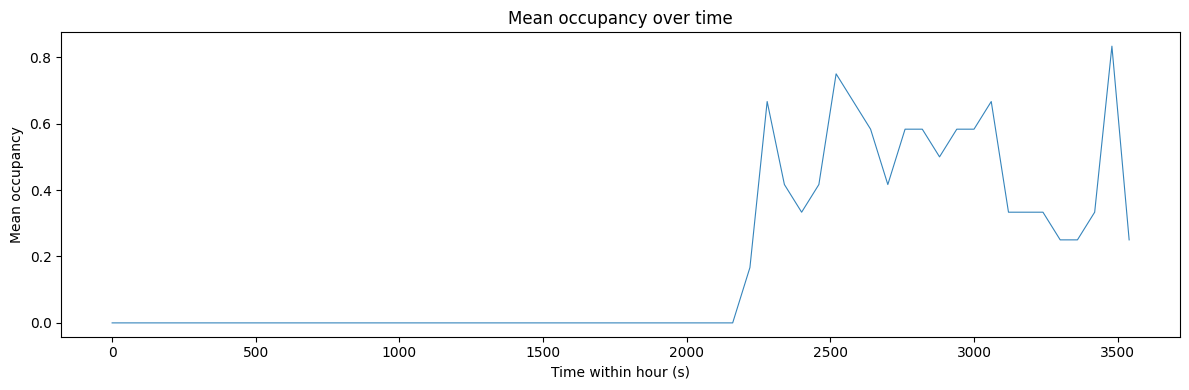

In [4]:
if time_col and y_col:
    # One point per time bin: mean occupancy across channels
    mean_co = co_ot.mean(axis=1)
    t_plot = time_sec
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(t_plot, mean_co, linewidth=0.8, alpha=0.9)
    ax.set_title("Mean occupancy over time")
    ax.set_xlabel("Time within hour (s)")
    ax.set_ylabel("Mean occupancy")
    plt.tight_layout()
    plt.show()
else:
    print("No time or Y column.")

## Frequency vs value heatmap

Same as cablelabs2 heatmap concept: 2D view of **frequency vs value**. For CSV: **time (x) vs frequency (y)**, color = channel occupancy (same as notebook 2 heatmap).

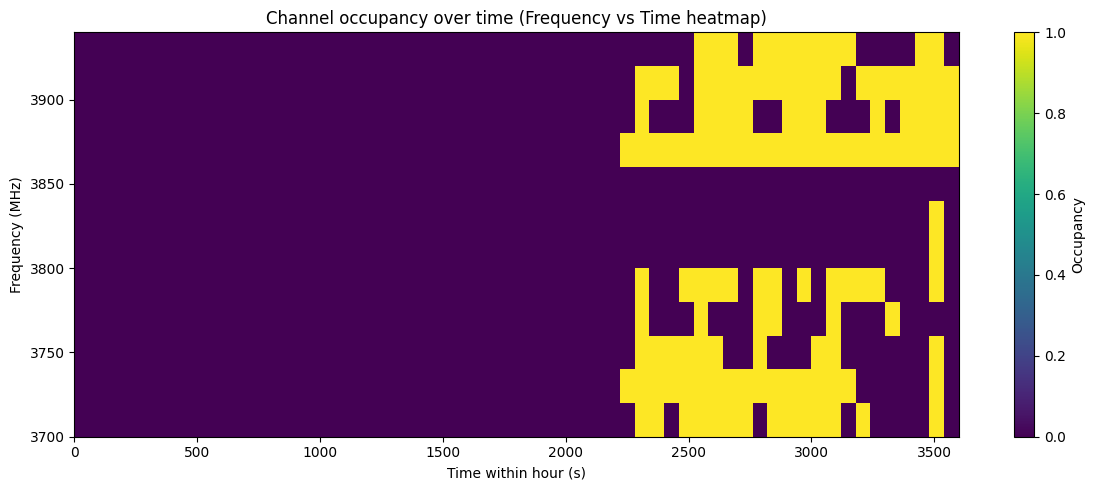

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(t_edges, freq_edges, co_ot.T, shading="flat", cmap="viridis", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Occupancy")
ax.set_title("Channel occupancy over time (Frequency vs Time heatmap)")
ax.set_xlabel("Time within hour (s)")
ax.set_ylabel("Frequency (MHz)")
plt.tight_layout()
plt.show()

## Frequency vs Airtime utilization (CSV analogue of Frequency vs Trace Max)

**Why there is no "Frequency vs Trace Max" from CSV:** The transform does not write `trace_max` (power in dBm) to the CSV. It only outputs **occupancy** (CO) and **airtime utilization** (AU) per channel. So we cannot plot frequency vs trace_max from CSV.

**CSV analogue:** Same idea — frequency on one axis, an intensity metric on the other. We plot **Frequency (channel center, MHz) vs Airtime utilization (AU %)** below (bar chart, same concept as notebook 3’s Frequency vs Trace Max heatmap).

In [ ]:
# Frequency (MHz) vs Airtime utilization (%) — CSV analogue of "Frequency vs Trace Max"
fig, ax = plt.subplots(figsize=(12, 5))
w = (0.9 * (freq_centers[1] - freq_centers[0])) if len(freq_centers) > 1 else 0.8
ax.bar(freq_centers, au_per_hour, width=w, align="center", color="steelblue", edgecolor="navy", alpha=0.8)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Airtime utilization (%)")
ax.set_title("Frequency vs Airtime utilization (CSV analogue of Frequency vs Trace Max)")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## Distribution

Histogram of selected numeric values. For CSV: **distribution of occupancy** (all CO values) and optionally **distribution of AU** (per-channel airtime utilization).

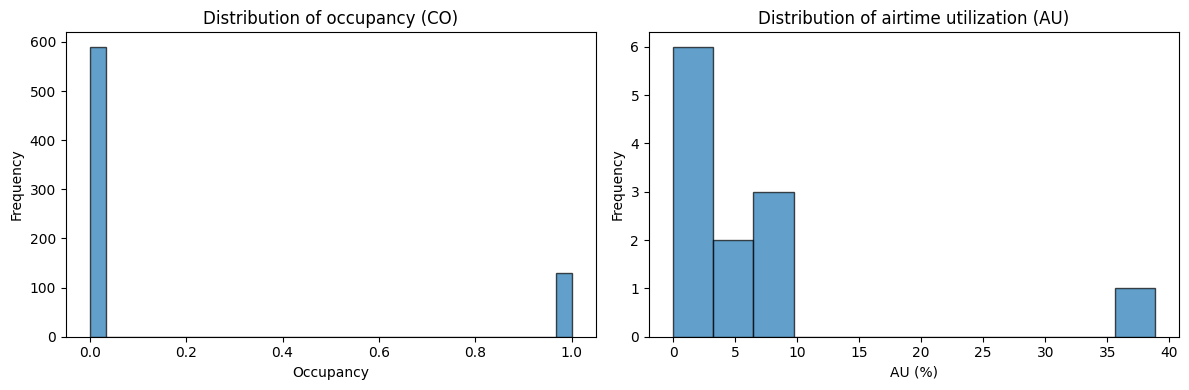

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(co_ot.flatten(), bins=30, edgecolor="black", alpha=0.7)
ax1.set_title("Distribution of occupancy (CO)")
ax1.set_xlabel("Occupancy")
ax1.set_ylabel("Frequency")
ax2.hist(au_per_hour, bins=min(20, max(1, n_chans)), edgecolor="black", alpha=0.7)
ax2.set_title("Distribution of airtime utilization (AU)")
ax2.set_xlabel("AU (%)")
ax2.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## Correlation heatmap

Correlation matrix of numeric columns. For CSV: **correlation between channels** (across time bins) using the CO matrix.

/Users/pradeep/workspace/nikhita/cablelabs-3/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/pradeep/workspace/nikhita/cablelabs-3/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


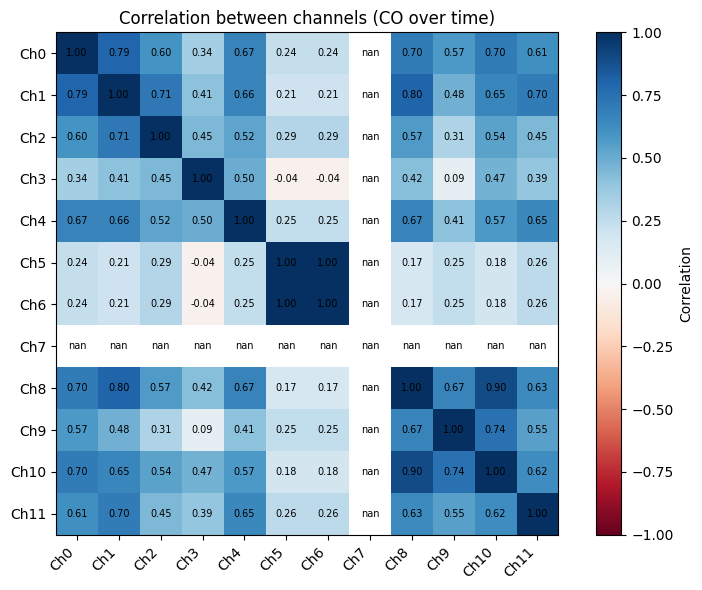

In [7]:
if n_chans > 1:
    corr = np.corrcoef(co_ot.T)  # (n_chans, n_chans)
    chan_labels = [f"Ch{i}" for i in range(n_chans)]
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr, cmap="RdBu", vmin=-1, vmax=1)
    ax.set_xticks(range(n_chans))
    ax.set_xticklabels(chan_labels, rotation=45, ha="right")
    ax.set_yticks(range(n_chans))
    ax.set_yticklabels(chan_labels)
    for i in range(n_chans):
        for j in range(n_chans):
            ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, label="Correlation")
    ax.set_title("Correlation between channels (CO over time)")
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 2 channels for correlation heatmap.")

## Data preview

First 100 rows (same as cablelabs2 data table). Here: first rows of the long-format dataframe (time_sec, freq_mhz, occupancy, datetime).

In [8]:
display(df.head(100))

,time_sec,freq_mhz,occupancy,datetime
0,0.0,3710.0,0.0,2026-02-01 00:00:00
1,0.0,3730.0,0.0,2026-02-01 00:00:00
2,0.0,3750.0,0.0,2026-02-01 00:00:00
3,0.0,3770.0,0.0,2026-02-01 00:00:00
4,0.0,3790.0,0.0,2026-02-01 00:00:00
...,...,...,...,...
95,420.0,3930.0,0.0,2026-02-01 00:07:00
96,480.0,3710.0,0.0,2026-02-01 00:08:00
97,480.0,3730.0,1.0,2026-02-01 00:08:00
98,480.0,3750.0,1.0,2026-02-01 00:08:00
